# salvar df no bq

In [ ]:
from pandas_gbq import to_gbq
from datetime import datetime

# nome da tabela com data de hoje
today = datetime.now().strftime('%Y%m%d')
table_id = f"ML.df_data_{today}"

# upload para BigQuery
to_gbq(
    df,
    destination_table=table_id,
    project_id=project_id,
    if_exists='replace',  # ou 'append'
    progress_bar=True
)

100%|██████████| 1/1 [00:00<00:00, 7943.76it/s]


In [ ]:
pd.DataFrame(df).to_csv('dados_treino.csv', index=False)

#start

In [ ]:
 !pip install keras==2.4.1

INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install keras, keras==2.4.1 and tensorflow==2.19.0 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested keras==2.4.1
    tensorflow 2.19.0 depends on keras>=3.5.0
    The user requested keras==2.4.1
    tensorflow 2.21.0 depends on keras>=3.12.0
    The user requested keras==2.4.1
    tensorflow 2.20.0 depends on keras>=3.10.0
    The user requested keras==2.4.1
    tensorflow 2.19.1 depends on keras>=3.5.0
    The user requested keras==2.4.1
    tensorflow 2.18.1 depends on keras>=3.5.0
    The user requested keras==2.4.1
    tensorflow 2.18.0 depends on keras>=3.5.0
    The user requested keras==2.4.1
    tensorflow 

In [ ]:
!pip install tensorflow==1.13.1

ERROR: Could not find a version that satisfies the requirement tensorflow==1.13.1 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==1.13.1


In [ ]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

In [ ]:
!pip install tensorflow-gpu # =='1.13.1'

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
import tensorflow as tf
print(tf.__version__)
import pandas as pd
import numpy as np

2.19.0


#valdiar se esta na gpu

In [ ]:
import tensorflow as tf

print("GPUs disponíveis:", tf.config.list_physical_devices('GPU'))

GPUs disponíveis: []


In [ ]:
tf.debugging.set_log_device_placement(True)

# operação simples
a = tf.constant([[1.0, 2.0]])
b = tf.constant([[3.0], [4.0]])
c = tf.matmul(a, b)
print(c)

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op MatMul in device /job:localhost/replica:0/task:0/device:GPU:0
tf.Tensor([[11.]], shape=(1, 1), dtype=float32)


#autentificar

In [ ]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')


Authenticated


In [ ]:
# ler df ja pronto:

from google.colab import syntax
from pandas_gbq import read_gbq

project_id = 'local-bliss-359814'
query = syntax.sql('''
SELECT
  *
FROM
  `ML.df_data_20260328`
''')

# Use pandas_gbq em vez de pd.io.gbq
df = read_gbq(query, project_id=project_id, dialect='standard', progress_bar_type='tqdm')

df.head()

Downloading: 100%|██████████|


,datahora,previsao,hi_temp,out_hum,wind_speed,wind_dir,vento_num,bar,fase_lua,direcao_6m_deg,...,altura_mare,CACHOEIRA DO SUL,CANOAS,GRAVATAI,NOVO HAMBURGO,PORTO ALEGRE,RIO GRANDE,SANTA CRUZ DO SUL,SANTA MARIA,SAO LEOPOLDO
0,1970-01-19 06:17:16.800,0.16,0.000000,0.0,0.0,0.0,0.0,0.000000,0.5,7.0,...,0.15,1.6,17.200001,8.8,12.1,13.1,5.3,2.5,2.2,20.200001
1,1970-01-19 06:17:20.400,0.18,26.500000,85.0,0.0,0.0,14.0,1004.000000,0.5,7.0,...,0.15,1.6,17.200001,8.8,12.1,13.1,5.3,2.5,2.2,20.200001
2,1970-01-19 06:17:24.000,0.17,26.200001,89.0,0.0,0.0,14.0,1003.900024,0.5,8.0,...,0.20,1.6,17.200001,8.8,12.1,13.1,5.3,2.5,2.2,20.200001
3,1970-01-19 06:17:27.600,0.14,25.200001,89.0,7.8,0.0,12.0,1003.400024,0.5,10.0,...,0.20,1.6,17.200001,8.8,12.1,13.1,5.3,2.5,2.2,20.200001
4,1970-01-19 06:17:31.200,0.13,24.700001,89.0,8.7,0.0,13.0,1003.599976,0.5,2.0,...,0.15,1.6,17.200001,8.8,12.1,13.1,5.3,2.5,2.2,20.200001


In [ ]:
df

,datahora,previsao,hi_temp,out_hum,wind_speed,wind_dir,vento_num,bar,fase_lua,direcao_6m_deg,...,altura_mare,CACHOEIRA DO SUL,CANOAS,GRAVATAI,NOVO HAMBURGO,PORTO ALEGRE,RIO GRANDE,SANTA CRUZ DO SUL,SANTA MARIA,SAO LEOPOLDO
0,1970-01-19 06:17:16.800,0.16,0.000000,0.0,0.0,0.0,0.0,0.000000,0.5,7.0,...,0.15,1.6,17.200001,8.8,12.1,13.100000,5.3,2.5,2.2,20.200001
1,1970-01-19 06:17:20.400,0.18,26.500000,85.0,0.0,0.0,14.0,1004.000000,0.5,7.0,...,0.15,1.6,17.200001,8.8,12.1,13.100000,5.3,2.5,2.2,20.200001
2,1970-01-19 06:17:24.000,0.17,26.200001,89.0,0.0,0.0,14.0,1003.900024,0.5,8.0,...,0.20,1.6,17.200001,8.8,12.1,13.100000,5.3,2.5,2.2,20.200001
3,1970-01-19 06:17:27.600,0.14,25.200001,89.0,7.8,0.0,12.0,1003.400024,0.5,10.0,...,0.20,1.6,17.200001,8.8,12.1,13.100000,5.3,2.5,2.2,20.200001
4,1970-01-19 06:17:31.200,0.13,24.700001,89.0,8.7,0.0,13.0,1003.599976,0.5,2.0,...,0.15,1.6,17.200001,8.8,12.1,13.100000,5.3,2.5,2.2,20.200001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41368,1970-01-21 12:54:27.120,0.20,21.100000,86.0,7.8,0.0,4.0,1017.700012,0.5,0.0,...,-0.16,14.2,3.000000,9.7,1.0,16.799999,0.0,13.5,22.5,1.400000
41369,1970-01-21 12:54:30.720,0.25,21.299999,85.0,6.1,0.0,5.0,1018.000000,0.5,0.0,...,0.00,14.2,3.000000,9.7,1.0,16.799999,0.0,13.5,22.5,1.400000
41370,1970-01-21 12:54:34.320,0.28,21.600000,85.0,6.1,0.0,4.0,1018.400024,0.5,0.0,...,0.02,14.2,3.000000,9.7,1.0,16.799999,0.0,13.5,22.5,1.400000
41371,1970-01-21 12:54:37.920,0.33,21.100000,88.0,7.0,0.0,3.0,1018.099976,0.5,0.0,...,0.12,14.2,3.000000,9.7,1.0,16.799999,0.0,13.5,22.5,1.400000


# ler df brutpo e tratar, ao r´pecisa ler la de baixo os openmeto tbm

In [ ]:
from google.colab import syntax
from pandas_gbq import read_gbq

project_id = 'local-bliss-359814'
query = syntax.sql('''
SELECT
  *
FROM
  `ML.xtrain_horario_t_2026`
''')

# Use pandas_gbq em vez de pd.io.gbq
df = read_gbq(query, project_id=project_id, dialect='standard', progress_bar_type='tqdm')

df.head()


Downloading: 100%|██████████|


,datahora,previsao,temp_out,hi_temp,out_hum,wind_speed,wind_dir,vento_num,bar,fase_lua,direcao_6m_deg,direcao_superficie_deg,direcao_3m_deg,intensidade_6m_kt,intensidade_superficie_kt,intensidade_3m_kt,altura_mare
0,2020-01-01 00:00:00,0.160000000,None,None,None,None,None,<NA>,None,0.5,7,7,7,1.030000000,0.450000000,1.110000000,0.150000000
1,2020-01-01 01:00:00,0.180000000,None,26.500000000,85.000000000,None,NW,14,1004.000000000,0.5,7,8,8,0.730000000,0.160000000,0.960000000,0.150000000
2,2020-01-01 02:00:00,0.170000000,None,26.200000000,89.000000000,None,NW,14,1003.900000000,0.5,8,9,8,0.500000000,0.070000000,0.740000000,0.200000000
3,2020-01-01 03:00:00,0.140000000,None,25.200000000,89.000000000,7.800000000,W,12,1003.400000000,0.5,10,0,7,0.010000000,0.090000000,0.400000000,0.200000000
4,2020-01-01 04:00:00,0.130000000,None,24.700000000,89.000000000,8.700000000,WNW,13,1003.600000000,0.5,2,0,7,0.150000000,0.230000000,0.570000000,0.150000000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
num_colunas = df.shape[1]
print(num_colunas)

25


In [ ]:
for col in df.columns:
    print(col)
    print(df[col].head())

datahora
0   1970-01-19 06:17:16.800
1   1970-01-19 06:17:20.400
2   1970-01-19 06:17:24.000
3   1970-01-19 06:17:27.600
4   1970-01-19 06:17:31.200
Name: datahora, dtype: datetime64[us]
previsao
0    0.16
1    0.18
2    0.17
3    0.14
4    0.13
Name: previsao, dtype: float64
hi_temp
0     0.000000
1    26.500000
2    26.200001
3    25.200001
4    24.700001
Name: hi_temp, dtype: float64
out_hum
0     0.0
1    85.0
2    89.0
3    89.0
4    89.0
Name: out_hum, dtype: float64
wind_speed
0    0.0
1    0.0
2    0.0
3    7.8
4    8.7
Name: wind_speed, dtype: float64
wind_dir
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: wind_dir, dtype: float64
vento_num
0     0.0
1    14.0
2    14.0
3    12.0
4    13.0
Name: vento_num, dtype: float64
bar
0       0.000000
1    1004.000000
2    1003.900024
3    1003.400024
4    1003.599976
Name: bar, dtype: float64
fase_lua
0    0.5
1    0.5
2    0.5
3    0.5
4    0.5
Name: fase_lua, dtype: float64
direcao_6m_deg
0     7.0
1     7.0
2     8.0
3    10.0
4

# tratar dados


In [ ]:
df_safe = df.copy()

In [ ]:
#usar só se ta baixanro open meteo e n o pronto
import pandas as pd

# garantir datetime
df['datahora'] = pd.to_datetime(df['datahora'])
df_final['time'] = pd.to_datetime(df_final['time'])

# criar coluna de data (sem hora)
df['date'] = df['datahora'].dt.date
df_final['date'] = df_final['time'].dt.date

df_pivot = df_final.pivot(
    index='date',
    columns='cidade',
    values='precipitation_sum'
).reset_index()

df_merged = df.merge(df_pivot, on='date', how='left')

df_merged = df_merged.drop(columns='date')

NameError: name 'df_final' is not defined

In [ ]:
df = df_merged

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PREPROCESSAMENTO EM df
# =========================

df = df.copy()

# drop coluna
df = df.drop(columns=['temp_out'], errors='ignore')

df = df.drop(columns=['wind_dir'], errors='ignore')
# =========================
# converter tudo para numérico
# =========================

df = df.apply(pd.to_numeric, errors='coerce')

# opcional: limpar NaN gerado pelo map
df = df.fillna(0)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PREPROCESSAMENTO EM df
# =========================

df = df.copy()

# drop coluna
df = df.drop(columns=['temp_out'], errors='ignore')


# =========================
# converter tudo para numérico
# =========================

df = df.apply(pd.to_numeric, errors='coerce')

# opcional: limpar NaN gerado pelo map
df = df.fillna(0)

# =========================
# datahora -> datetime
# =========================

if 'datahora' in df.columns:
    df['datahora'] = pd.to_datetime(df['datahora'], errors='coerce')

# se datahora for index
if df.index.name == 'datahora':
    df.index = pd.to_datetime(df.index, errors='coerce')

# =========================
# tudo -> numérico (exceto datahora)
# =========================

cols_to_convert = df.columns.drop('datahora', errors='ignore')

df[cols_to_convert] = df[cols_to_convert].apply(
    pd.to_numeric, errors='coerce'
)

# =========================
# substituir erros por 0
# =========================

df[cols_to_convert] = df[cols_to_convert].fillna(0)

# opcional: garantir tipo float32 (mais leve)
df[cols_to_convert] = df[cols_to_convert].astype(np.float32)


Definição formal do que você quer
Target (y):
intensidade_3m_kt e direcao_3m_deg
com lead = +2 passos (ou seja, prever t+2)
Features (X_o):
lags (passado): últimos 3 passos → t, t-1, t-2
leads (futuro): próximos 6 passos → t+1 … t+6
excluir dos leads: variáveis de correnteza (intensidade_*, direcao_*)
demais variáveis podem usar futuro (porque já são previsões)

In [ ]:
df = df.sort_values("datahora").reset_index(drop=True)

# =========================
# TARGET (y) com lead +2
# =========================
y = df[["intensidade_3m_kt"]].shift(-2) # , "direcao_3m_deg"

# =========================
# FEATURES (X_o)
# =========================

# colunas
target_cols = ["intensidade_3m_kt"] # , "direcao_3m_deg"

# variáveis de correnteza (não usar no futuro)
corrente_cols = [c for c in df.columns if "intensidade" in c or "direcao" in c]

# todas exceto datahora
base_cols = [c for c in df.columns if c != "datahora"]

X_parts = []

# ---------
# LAGS (t, t-1, t-2)
# tudo incluso
# ---------
for lag in range(0, 6):
    X_lag = df[base_cols].shift(lag)
    X_lag.columns = [f"{c}_lag{lag}" for c in base_cols]
    X_parts.append(X_lag)

# ---------
# LEADS (t+1 ... t+6)
# exclui correnteza
# ---------
lead_cols = [c for c in base_cols if c not in corrente_cols]

for lead in range(1, 7):
    X_lead = df[lead_cols].shift(-lead)
    X_lead.columns = [f"{c}_lead{lead}" for c in lead_cols]
    X_parts.append(X_lead)

# concatena tudo
X_o = pd.concat(X_parts, axis=1)

# =========================
# LIMPEZA FINAL
# =========================
data = pd.concat([X_o, y], axis=1).dropna()


# remove linhas onde intensidade == 0
data = data[data["intensidade_3m_kt"] != 0]

X_o = data[X_o.columns]
y = data[y.columns]

In [ ]:
print(df.dtypes)
print(df.isna().sum().sum())  # deve ser 0 (exceto datetime inválido)

datahora                     datetime64[ns]
previsao                            float32
hi_temp                             float32
out_hum                             float32
wind_speed                          float32
vento_num                           float32
bar                                 float32
fase_lua                            float32
direcao_6m_deg                      float32
direcao_superficie_deg              float32
direcao_3m_deg                      float32
intensidade_6m_kt                   float32
intensidade_superficie_kt           float32
intensidade_3m_kt                   float32
altura_mare                         float32
CACHOEIRA DO SUL                    float32
CANOAS                              float32
GRAVATAI                            float32
NOVO HAMBURGO                       float32
PORTO ALEGRE                        float32
RIO GRANDE                          float32
SANTA CRUZ DO SUL                   float32
SANTA MARIA                     

In [ ]:
X_o.shape


(38661, 240)

In [ ]:
y.shape

(38661, 1)

# PLotting

In [ ]:
df = df.set_index("datahora")


In [ ]:
cols_to_drop = [c for c in X_o.columns if "wind_dir" in c]
X_o = X_o.drop(columns=cols_to_drop)

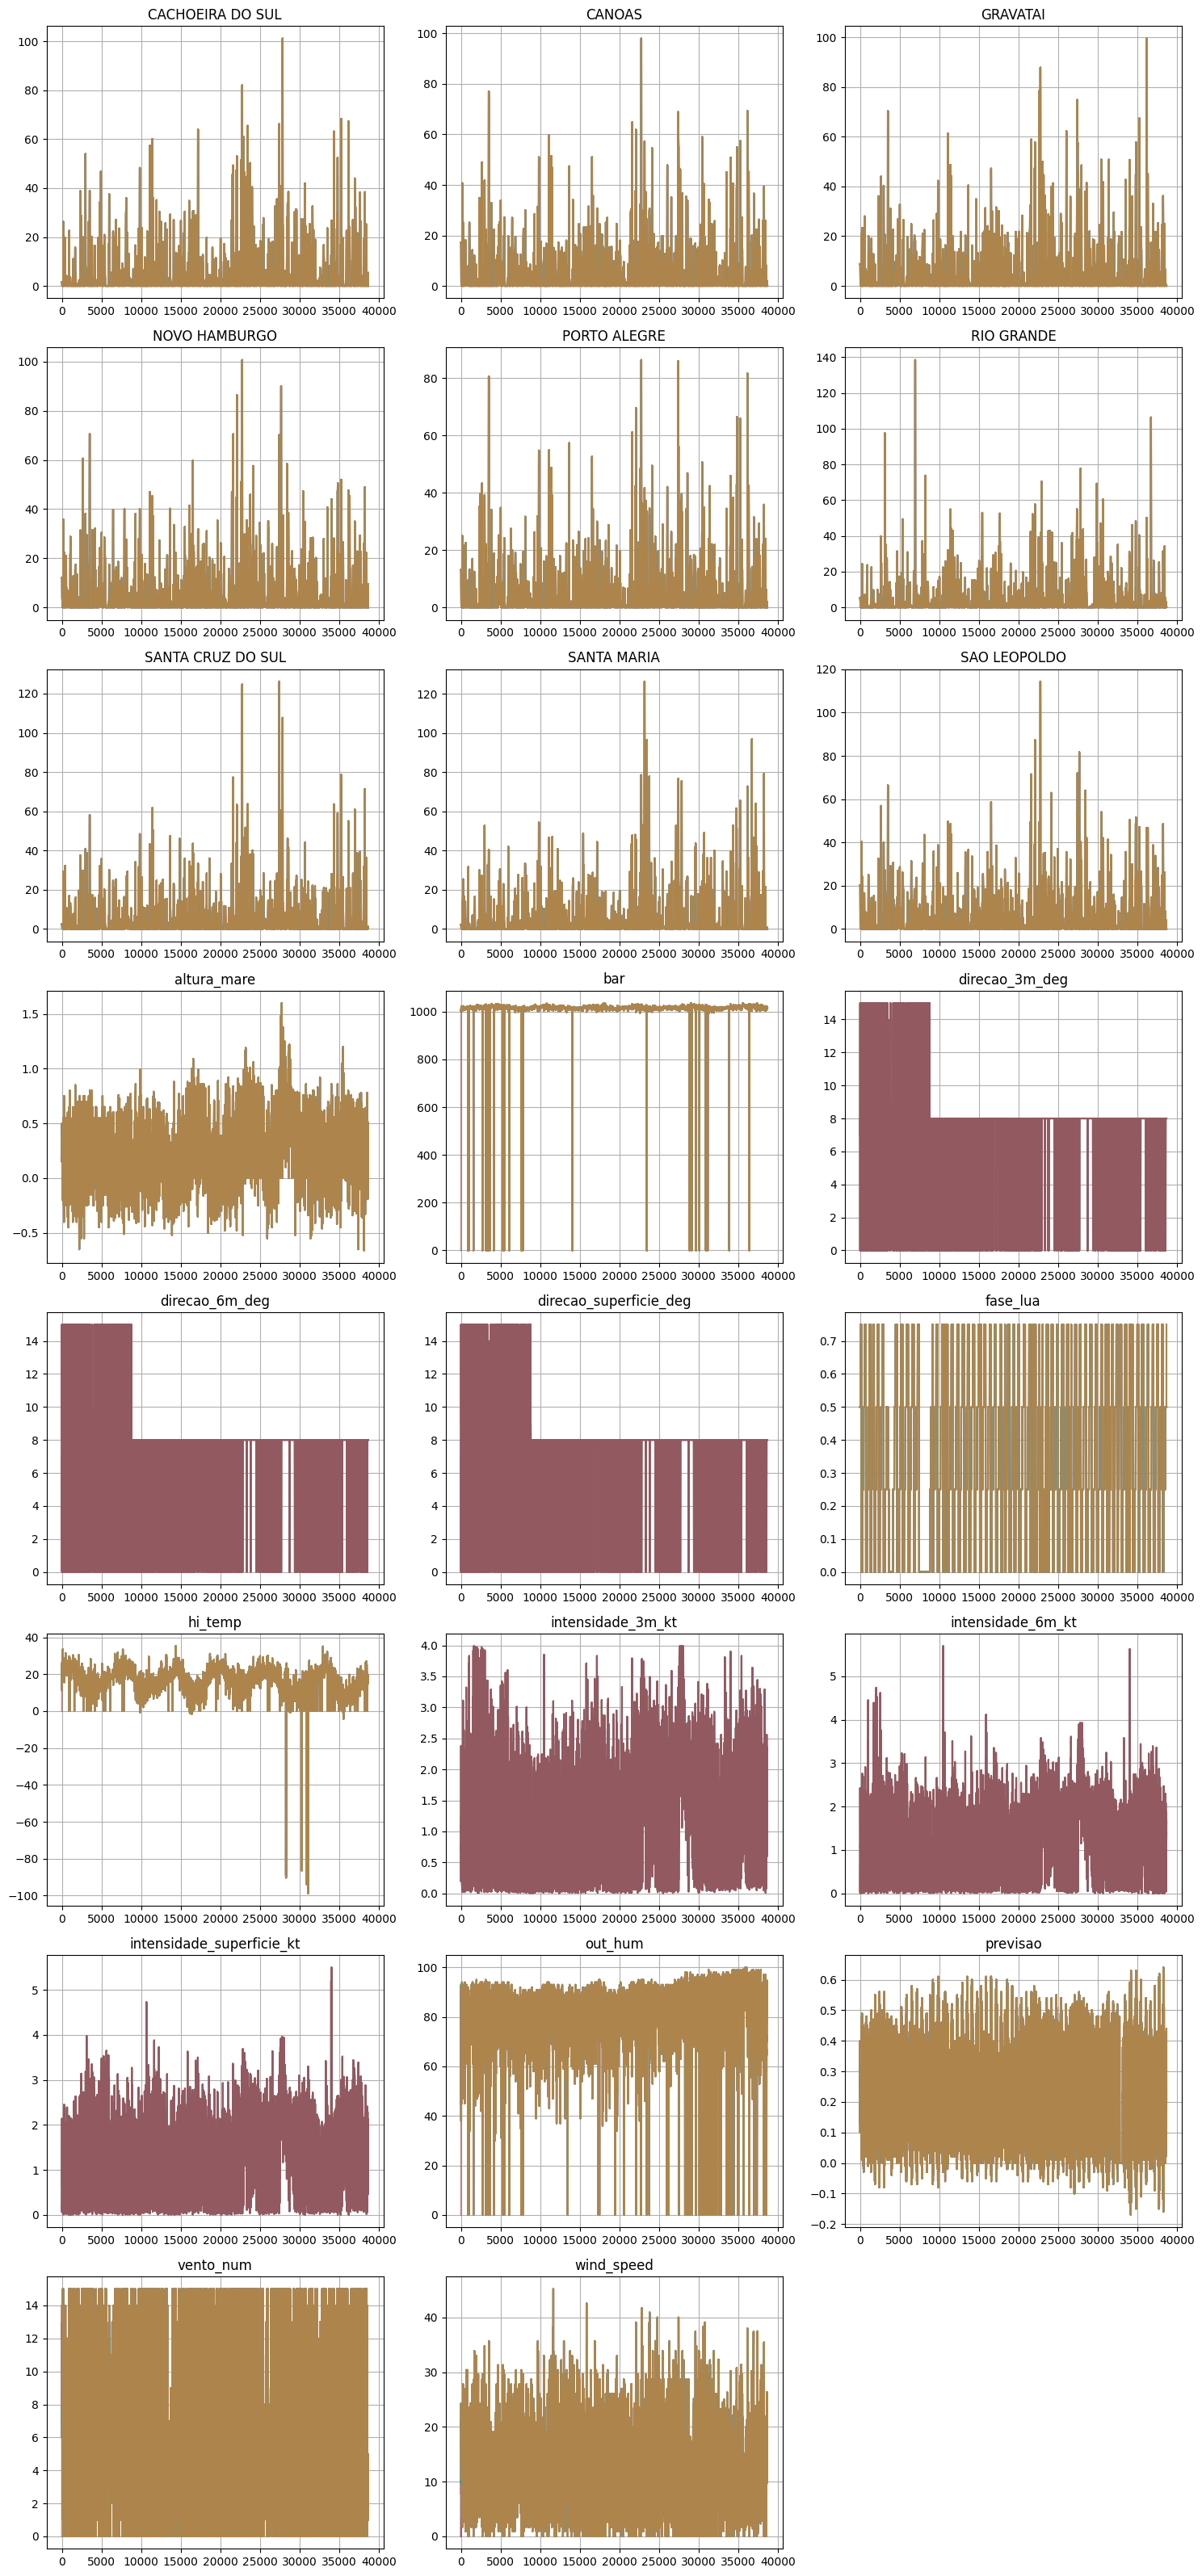

In [ ]:

base_vars = sorted(set(c.split("_lag")[0].split("_lead")[0] for c in X_o.columns))

n_cols = 3
n_rows = int(np.ceil(len(base_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(base_vars):
    related_cols = [c for c in X_o.columns if c.startswith(var)]

    for col in related_cols:
        axes[i].plot(X_o.index, X_o[col], alpha=0.6)

    axes[i].set_title(var)
    axes[i].grid(True)

# remover vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Fas merged

In [ ]:
df.fillna(0, inplace=True)

In [ ]:
percent_zeros = ((X_o == 0).mean() * 100).sort_values(ascending=False)

print(percent_zeros)

CACHOEIRA DO SUL_lead4            50.703497
CACHOEIRA DO SUL_lead6            50.703497
CACHOEIRA DO SUL_lead2            50.703497
CACHOEIRA DO SUL_lead3            50.703497
CACHOEIRA DO SUL_lead5            50.703497
                                    ...    
intensidade_superficie_kt_lag1     0.025864
intensidade_superficie_kt_lag2     0.025864
intensidade_3m_kt_lag0             0.010346
intensidade_3m_kt_lag1             0.010346
intensidade_3m_kt_lag2             0.010346
Length: 171, dtype: float64


# rum model

(30928, 240)
(7733, 240)


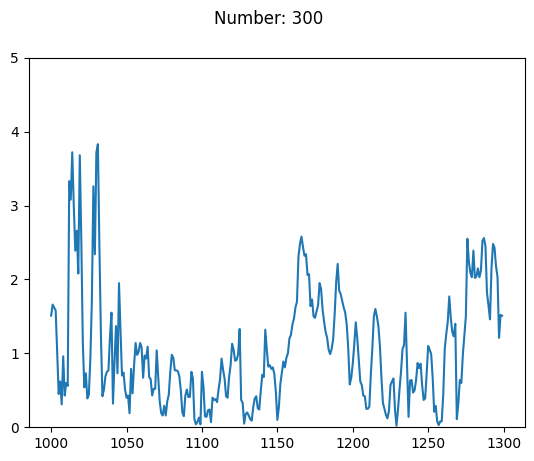

In [ ]:

# =========================
# SPLIT (80/20 temporal)
# =========================
def normalize_minmax(X):
    X = np.array(X, dtype=np.float32)
    min_vals = X.min(axis=0)
    max_vals = X.max(axis=0)

    denom = max_vals - min_vals
    denom[denom == 0] = 1.0

    X_norm = (X - min_vals) / denom
    return X_norm, min_vals, max_vals




split = int(len(X_o) * 0.8)
trainX, testX = X_o.iloc[:split], X_o.iloc[split:]
trainY, testY = y.iloc[:split], y.iloc[split:]

print(trainX.shape)
print(testX.shape)

# =========================
# VISUALIZAÇÃO
# =========================

plttam = 300
plt.ylim([0, 5])
plt.plot(range(1000,1000+plttam), trainY.iloc[1000:1000+plttam])
plt.suptitle('Number: ' + str(plttam))
plt.show()

# =========================
# CONFIG
# =========================

USE_NORMALIZATION = True  # <<< MUDE AQUI

# =========================
# SPLIT (80/20 temporal)
# =========================

split = int(len(X_o) * 0.92)
trainX, testX = X_o.iloc[:split], X_o.iloc[split:]
trainY, testY = y.iloc[:split], y.iloc[split:]

# =========================
# LIMPEZA NUMÉRICA FINAL
# =========================

trainX = np.nan_to_num(trainX.to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)
testX  = np.nan_to_num(testX.to_numpy(),  nan=0.0, posinf=0.0, neginf=0.0)

trainY = np.nan_to_num(trainY.to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)
testY  = np.nan_to_num(testY.to_numpy(),  nan=0.0, posinf=0.0, neginf=0.0)

# =========================
# NORMALIZAÇÃO (CONDICIONAL)
# =========================

if USE_NORMALIZATION:
    # X
    trainX, min_vals, max_vals = normalize_minmax(trainX)
    testX = (testX - min_vals) / (max_vals - min_vals + 1e-8)

    # Y
    trainY, minY, maxY = normalize_minmax(trainY)
    testY = (testY - minY) / (maxY - minY + 1e-8)

else:
    # mantém dados originais
    min_vals, max_vals = None, None
    minY, maxY = None, None

# Rodar treino

In [ ]:
#Build the Graph
#Clear any existing model in memory
tam = trainX.shape[1]
print('model imputs tam:', tam )
tf.keras.backend.clear_session()
#Initialize Sequential model
model = tf.keras.models.Sequential()
#imputlayer
model.add(tf.keras.layers.Dense(tam, input_shape=(tam,)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(220, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(200, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(150, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(80, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(30, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(10, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(5, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(2, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
# output
model.add(tf.keras.layers.Dense(2, activation='linear'))

#Compile the model
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.005, momentum=0.90)

model.compile(optimizer=sgd_optimizer,
              loss='mean_absolute_error',
              metrics=['mean_squared_error']) #  accuracy hinge mean_squared_error
#Review model
model.summary()
#Train the model
mckpt = tf.keras.callbacks.ModelCheckpoint('mnist_sgd_mom.keras',
                                           monitor='val_mean_squared_error', save_best_only=True, verbose=1)
model.fit(trainX,trainY,
          validation_data=(testX,testY),
          epochs=4,
          batch_size=32,
          callbacks = [mckpt])

model.compile(optimizer='sgd', loss='mean_squared_error', metrics=['mean_squared_error'])
model.save('mnist_sgd.keras')

#Save the model in current directory
model.save('mnist_dnn_v1.keras')


model imputs tam: 240


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 240)            │        57,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 240)            │           960 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 220)            │        53,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 220)            │           880 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │        44,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 150)            │           600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        15,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 80)             │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 80)             │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80)             │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │         2,430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │             

 Total params: 235,751 (920.90 KB)

 Trainable params: 233,197 (910.93 KB)

 Non-trainable params: 2,554 (9.98 KB)

Epoch 1/4
1109/1112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2373 - mean_squared_error: 0.3114
Epoch 1: val_mean_squared_error improved from None to 0.03050, saving model to mnist_sgd_mom.keras

Epoch 1: finished saving model to mnist_sgd_mom.keras
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.1624 - mean_squared_error: 0.0908 - val_loss: 0.1411 - val_mean_squared_error: 0.0305
Epoch 2/4
1108/1112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1227 - mean_squared_error: 0.0253
Epoch 2: val_mean_squared_error improved from 0.03050 to 0.01654, saving model to mnist_sgd_mom.keras

Epoch 2: finished saving model to mnist_sgd_mom.keras
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.1173 - mean_squared_error: 0.0232 - val_loss: 0.1010 - val_mean_squared_error: 0.0165
Epoch 3/4
1110/1112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1045 - mean_squared_error: 0.0186
Epoch 3: val_mean_squared_error improved from 0.01654 to 0.01078, saving model to mnist_sgd_mom.keras

Epoch 3: finish

In [ ]:
print("Colunas usadas em X:")
print(X.columns.tolist())

Colunas usadas em X:


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

# Evolutivo

In [ ]:
def treinar_com_acuracia(
    model,
    trainX, trainY,
    testX, testY,
    minY, maxY,
    epochs=50,
    threshold=0.5,
    idx_intensidade=0
):
    import numpy as np
    import matplotlib.pyplot as plt

    acc_hist = []

    for ep in range(epochs):
        print(f"\nEpoch {ep+1}/{epochs}")

        # treina 1 época
        model.fit(
            trainX, trainY,
            validation_data=(testX, testY),
            epochs=1,
            batch_size=32,
            verbose=0
        )

        # previsão
        pred = model.predict(testX, verbose=0)

        # =========================
        # DESNORMALIZA
        # =========================
        y_true = testY * (maxY - minY + 1e-8) + minY
        y_pred = pred * (maxY - minY + 1e-8) + minY

        # intensidade
        yt = y_true[:, idx_intensidade]
        yp = y_pred[:, idx_intensidade]

        # erro
        erro = np.abs(yt - yp)

        # acurácia
        acc = np.mean(erro < threshold) * 100
        acc_hist.append(acc)

        print(f"Acurácia (<{threshold}): {acc:.3f}%")

    # =========================
    # PLOT
    # =========================
    plt.figure()
    plt.plot(acc_hist)
    plt.title("Evolução da Acurácia (%)")
    plt.xlabel("Época")
    plt.ylabel("Acurácia (%)")
    plt.grid(True)
    plt.show()

    return acc_hist


Epoch 1/15
Acurácia (<0.5): 86.841%

Epoch 2/15
Acurácia (<0.5): 87.488%

Epoch 3/15
Acurácia (<0.5): 87.100%

Epoch 4/15
Acurácia (<0.5): 87.456%

Epoch 5/15
Acurácia (<0.5): 87.520%

Epoch 6/15
Acurácia (<0.5): 88.038%

Epoch 7/15
Acurácia (<0.5): 88.167%

Epoch 8/15
Acurácia (<0.5): 88.490%

Epoch 9/15
Acurácia (<0.5): 88.587%

Epoch 10/15
Acurácia (<0.5): 88.231%

Epoch 11/15
Acurácia (<0.5): 88.231%

Epoch 12/15
Acurácia (<0.5): 88.587%

Epoch 13/15
Acurácia (<0.5): 87.714%

Epoch 14/15
Acurácia (<0.5): 88.134%

Epoch 15/15
Acurácia (<0.5): 87.876%


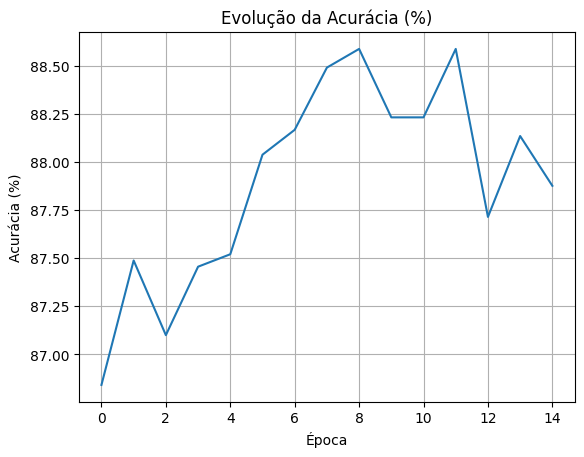

In [ ]:
acc_hist = treinar_com_acuracia(
    model,
    trainX, trainY,
    testX, testY,
    minY, maxY,
    epochs=15,
    threshold=0.5
)

In [ ]:
def plot_amostras_aleatorias(
    model,
    testX, testY,
    minY, maxY,
    n_samples=5,
    window=100,
    idx_intensidade=0
):
    import numpy as np
    import matplotlib.pyplot as plt

    # previsão
    pred = model.predict(testX, verbose=0)

    # =========================
    # DESNORMALIZA
    # =========================
    y_true = testY * (maxY - minY + 1e-8) + minY
    y_pred = pred * (maxY - minY + 1e-8) + minY

    # garante espaço suficiente pra janela
    max_start = len(y_true) - window
    idxs = np.random.choice(max_start, size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 1, figsize=(12, 3 * n_samples))

    if n_samples == 1:
        axes = [axes]

    for i, idx in enumerate(idxs):
        real = y_true[idx:idx+window, idx_intensidade]
        predv = y_pred[idx:idx+window, idx_intensidade]

        axes[i].plot(real, label="Real")
        axes[i].plot(predv, label="Previsto")

        axes[i].set_title(f"Janela iniciando em {idx}")
        axes[i].grid(True)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

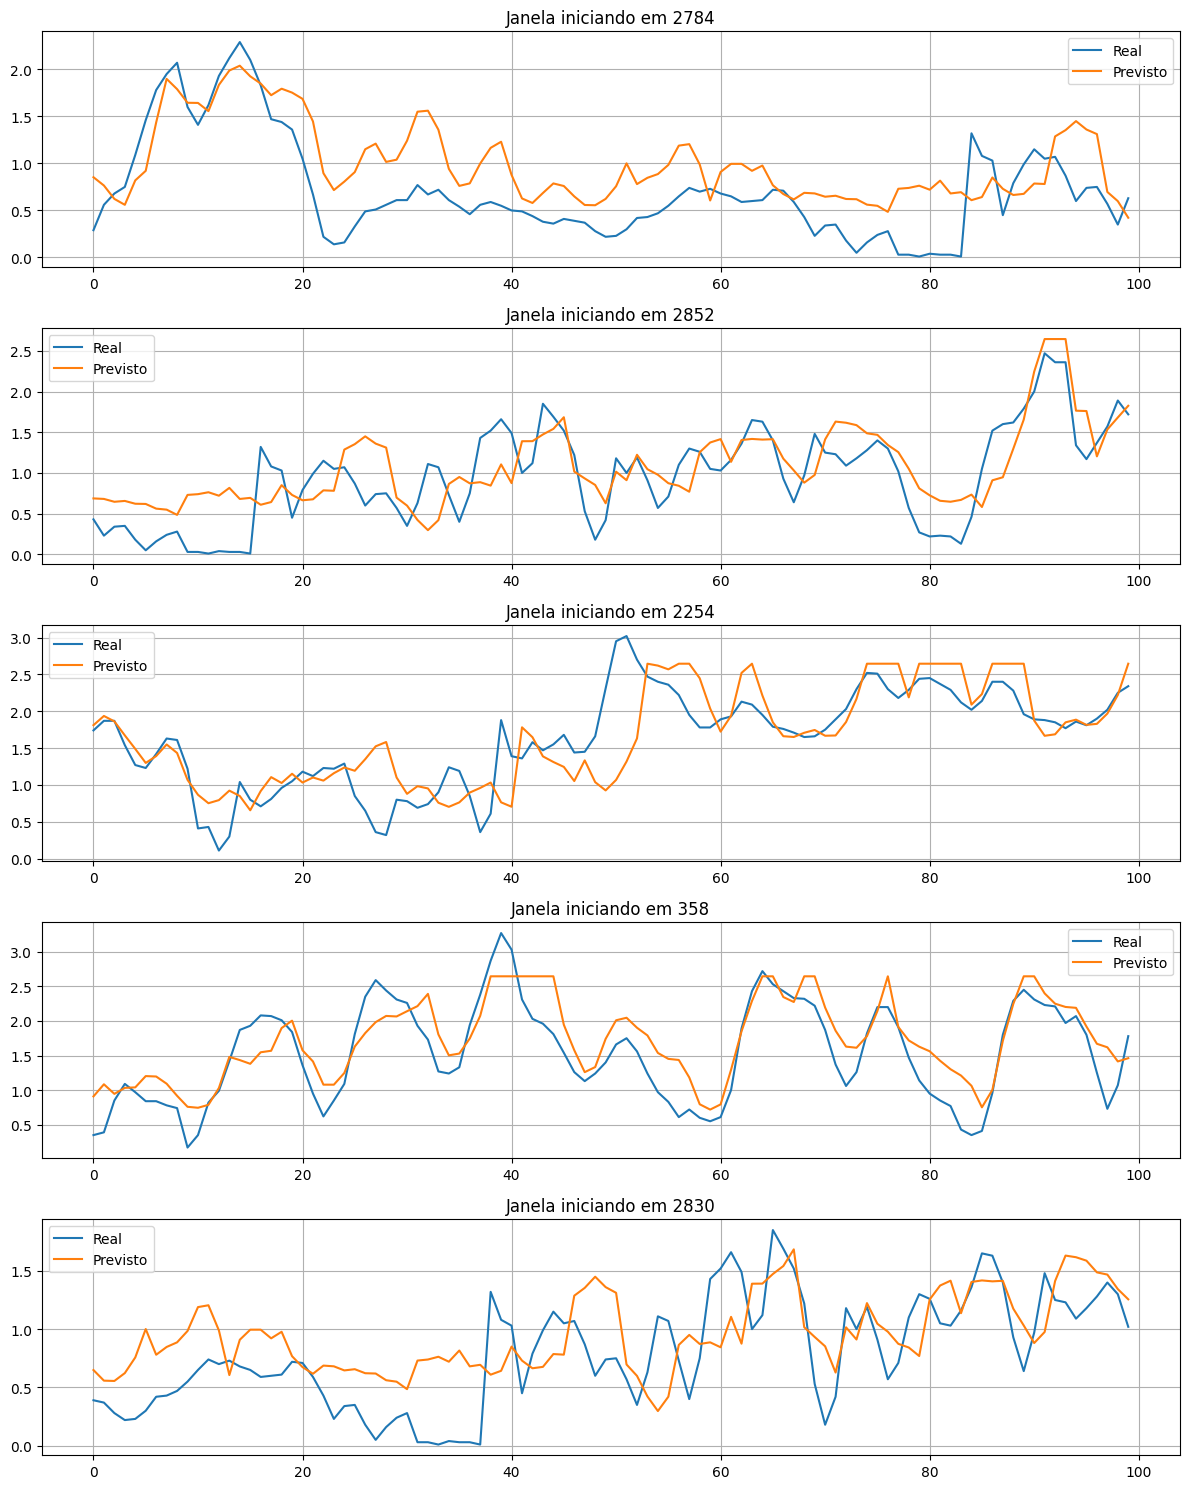

In [ ]:
plot_amostras_aleatorias(
    model,
    testX, testY,
    minY, maxY,
    n_samples=5,
    window=100
)

242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


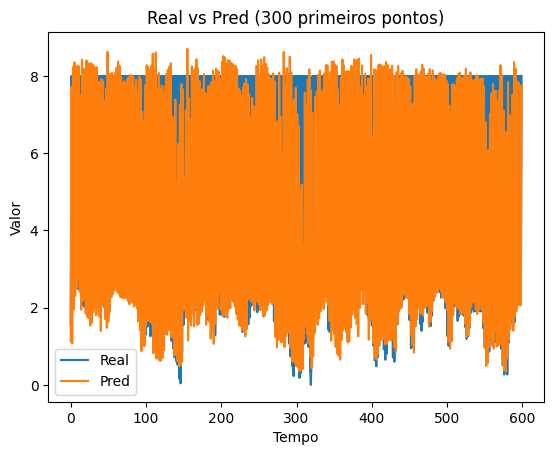

In [ ]:
# =========================
# PREVISÃO COMPLETA
# =========================

pred_full = model.predict(testX)

# denormaliza
pred_full = pred_full * (maxY - minY + 1e-8) + minY
real_full = testY * (maxY - minY + 1e-8) + minY

# =========================
# PLOT 300 PONTOS
# =========================

import matplotlib.pyplot as plt

n = 300

plt.figure()
plt.plot(real_full[:n].flatten(), label='Real')
plt.plot(pred_full[:n].flatten(), label='Pred')
plt.legend()

plt.title('Real vs Pred (300 primeiros pontos)')
plt.xlabel('Tempo')
plt.ylabel('Valor')

plt.show()

# Validação

In [ ]:
def acuracia_intensidade(
    y_true_norm,
    y_pred_norm,
    minY,
    maxY,
    idx_intensidade=0,   # índice da coluna de intensidade
    threshold=0.5
):
    # =========================
    # DESNORMALIZA
    # =========================
    y_true = y_true_norm * (maxY - minY + 1e-8) + minY
    y_pred = y_pred_norm * (maxY - minY + 1e-8) + minY

    # pega só intensidade
    y_true_i = y_true[:, idx_intensidade]
    y_pred_i = y_pred[:, idx_intensidade]

    # =========================
    # ERRO ABSOLUTO
    # =========================
    erro = np.abs(y_true_i - y_pred_i)

    # =========================
    # ACURÁCIA
    # =========================
    acertos = np.sum(erro < threshold)
    acc = acertos / len(erro) * 100

    return round(acc, 3)

In [ ]:
pred_test = model.predict(testX)

acc = acuracia_intensidade(
    testY,
    pred_test,
    minY,
    maxY,
    idx_intensidade=0,  # ajuste se necessário
    threshold=0.5
)

print(f"Acurácia (erro < 0.5): {acc}%")

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Acurácia (erro < 0.5): 83.317%


In [ ]:
pred_test = model.predict(trainX)

acc = acuracia_intensidade(
    trainY,
    pred_test,
    minY,
    maxY,
    idx_intensidade=0,  # ajuste se necessário
    threshold=0.5
)

print(f"Acurácia (erro < 0.5): {acc}%")

1112/1112 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
Acurácia (erro < 0.5): 88.149%


In [ ]:
def acuracia_multistep(y_true_norm, y_pred_norm, minY, maxY, threshold=0.5):
    y_true = y_true_norm * (maxY - minY + 1e-8) + minY
    y_pred = y_pred_norm * (maxY - minY + 1e-8) + minY

    accs = []
    for i in range(y_true.shape[1]):
        erro = np.abs(y_true[:, i] - y_pred[:, i])
        acc = np.mean(erro < threshold) * 100
        accs.append(round(acc, 3))

    return accs

In [ ]:
accs = acuracia_multistep(testY, pred_test, minY, maxY, threshold=0.5)

for i, acc in enumerate(accs):
    print(f"Step {i}: {acc}%")

Step 0: 84.966%
Step 1: 65.697%


#fazer previsao: (ajustar aqui)

In [ ]:
from google.colab import syntax
from pandas_gbq import read_gbq

project_id = 'local-bliss-359814'

query = syntax.sql('''
SELECT
  *
FROM
  `ML.xtrain_horario_t_2026`
ORDER BY
  datahora DESC
LIMIT 10
''')

df = read_gbq(query, project_id=project_id, dialect='standard', progress_bar_type='tqdm')

# ordenar crescente para modelagem temporal
df = df.sort_values('datahora').reset_index(drop=True)

df.head()

Downloading: 100%|██████████|


,datahora,previsao,temp_out,hi_temp,out_hum,wind_speed,wind_dir,vento_num,bar,fase_lua,direcao_6m_deg,direcao_superficie_deg,direcao_3m_deg,intensidade_6m_kt,intensidade_superficie_kt,intensidade_3m_kt,altura_mare
0,2026-03-25 14:32:00,0.210000000,21.900000000,21.200000000,76.000000000,7.800000000,SE,6,1016.800000000,0.5,0,0,0,0E-9,0E-9,0E-9,-0.120000000
1,2026-03-25 15:32:00,0.150000000,22.100000000,21.300000000,77.000000000,7.000000000,SE,6,1016.500000000,0.5,0,0,0,0E-9,0E-9,0E-9,-0.150000000
2,2026-03-25 16:32:00,0.070000000,22.300000000,21.200000000,81.000000000,8.700000000,E,4,1016.500000000,0.5,0,0,0,0E-9,0E-9,0E-9,-0.260000000
3,2026-03-25 17:32:00,0.050000000,21.400000000,19.700000000,86.000000000,10.400000000,ENE,3,1016.200000000,0.5,0,0,0,0E-9,0E-9,0E-9,-0.320000000
4,2026-03-25 18:31:00,0.120000000,21.400000000,20.600000000,86.000000000,7.800000000,ENE,3,1016.800000000,0.5,0,0,0,0E-9,0E-9,0E-9,-0.300000000


In [ ]:
import numpy as np
import pandas as pd

# supondo colunas:
# 'intensidade', 'direcao', 'datahora'

target_cols = ['intensidade', 'direcao']

# número de lags (ajuste conforme necessário)
n_lags = 3

def create_lagged(df, cols, n_lags):
    data = df.copy()
    for col in cols:
        for lag in range(1, n_lags+1):
            data[f'{col}_lag{lag}'] = data[col].shift(lag)
    return data.dropna()

df_lagged = create_lagged(df, target_cols, n_lags)

X = df_lagged.drop(columns=target_cols + ['datahora'])
y = df_lagged[target_cols]

In [ ]:
# =========================================
# CONFIG
# =========================================


target_cols = ['intensidade', 'direcao']
n_lags = 3
horizon = 6
USE_NORMALIZATION = True

# =========================================
# 1) LAGS
# =========================================
def create_lagged(df, cols, n_lags):
    data = df.copy()
    for col in cols:
        for lag in range(1, n_lags+1):
            data[f'{col}_lag{lag}'] = data[col].shift(lag)
    return data

# =========================================
# 2) MULTISTEP Y
# =========================================
def create_multistep_y(df, cols, horizon):
    data = pd.DataFrame(index=df.index)
    for col in cols:
        for h in range(1, horizon+1):
            data[f'{col}_t+{h}'] = df[col].shift(-h)
    return data

# =========================================
# 3) PIPELINE COMPLETO
# =========================================
df = df.sort_values('datahora').reset_index(drop=True)

df_lagged = create_lagged(df, target_cols, n_lags)
y_multi   = create_multistep_y(df_lagged, target_cols, horizon)

# juntar tudo e remover NaN
data_final = pd.concat([df_lagged, y_multi], axis=1).dropna()

# features e target
X_o = data_final.drop(columns=target_cols + ['datahora'] + list(y_multi.columns))
y   = data_final[y_multi.columns]

# =========================================
# 4) NUMPY + LIMPEZA
# =========================================
X_o = np.nan_to_num(X_o.to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)
y   = np.nan_to_num(y.to_numpy(),   nan=0.0, posinf=0.0, neginf=0.0)

# =========================================
# 5) PEGAR ÚLTIMA JANELA
# =========================================
testX = X_o[-1:].copy()
testY = y[-1:].copy()

# =========================================
# 6) NORMALIZAÇÃO (USA PARAMS DO TREINO)
# =========================================
if USE_NORMALIZATION:
    testX = (testX - min_vals) / (max_vals - min_vals + 1e-8)
    testY = (testY - minY) / (maxY - minY + 1e-8)

# =========================================
# 7) PREVISÃO
# =========================================
pred_test = model.predict(testX)

# desnormalizar
pred_real = pred_test * (maxY - minY + 1e-8) + minY

# =========================================
# 8) SEPARAR SAÍDAS
# =========================================
int_pred = pred_real[0][:horizon]
dir_pred = pred_real[0][horizon:]

# =========================================
# 9) TEMPO FUTURO
# =========================================
last_time = df['datahora'].iloc[-1]
future_times = [last_time + pd.Timedelta(hours=i+1) for i in range(horizon)]

# =========================================
# 10) PLOT
# =========================================
plt.figure(figsize=(12,8))

# Intensidade
plt.subplot(2,1,1)
plt.plot(df['datahora'], df['intensidade'], label='Real')
plt.plot(future_times, int_pred, '--', label='Previsto')
plt.title('Intensidade')
plt.legend()

# Direção
plt.subplot(2,1,2)
plt.plot(df['datahora'], df['direcao'], label='Real')
plt.plot(future_times, dir_pred, '--', label='Previsto')
plt.title('Direção')
plt.legend()

plt.tight_layout()
plt.show()

KeyError: 'intensidade'

In [ ]:
# Enable eager execution
tf.compat.v1.enable_eager_execution()

In [ ]:
for col in df.columns:
    if 'direcao' in col.lower():
        s = df[col]
        print(f'\nCOLUNA: {col}')
        print('dtype:', s.dtype)
        print('NaN:', s.isna().sum())
        print('Zeros:', (s == 0).sum())
        print('Únicos:', s.nunique())
        print('Valores únicos (amostra):', s.dropna().unique()[:10])


COLUNA: direcao_6m_deg
dtype: float32
NaN: 0
Zeros: 13236
Únicos: 16
Valores únicos (amostra): [ 7.  8. 10.  2.  5. 15.  0.  9.  3. 13.]

COLUNA: direcao_superficie_deg
dtype: float32
NaN: 0
Zeros: 12380
Únicos: 16
Valores únicos (amostra): [ 7.  8.  9.  0. 15.  6.  2. 13. 10.  5.]

COLUNA: direcao_3m_deg
dtype: float32
NaN: 0
Zeros: 12654
Únicos: 16
Valores únicos (amostra): [ 7.  8.  5.  0. 15. 13. 14.  4.  1.  2.]


# Get chuva

In [ ]:
trainX.shape[1]

171

In [ ]:
import requests
import pandas as pd
from datetime import date, timedelta
import time

cidades = [
    ("PORTO ALEGRE", "RS", -30.0324999, -51.2303767),
    ("CANOAS", "RS", -29.9216045, -51.1799525),
    ("SAO LEOPOLDO", "RS", -29.7544405, -51.1516497),
    ("NOVO HAMBURGO", "RS", -29.6905705, -51.1429035),
    ("GRAVATAI", "RS", -29.9440222, -50.9930938),
    ("SANTA MARIA", "RS", -29.6860512, -53.8069214),
    ("CACHOEIRA DO SUL", "RS", -30.0482234, -52.8901686),
    ("SANTA CRUZ DO SUL", "RS", -29.714209, -52.4285807),
    ("RIO GRANDE", "RS", -32.035, -52.0986)
]

# período (últimos 6 anos)
end_date = date.today()
start_date = end_date - timedelta(days=15) #7*365

dfs = []

for cidade, estado, lat, lon in cidades:
    print(f"Baixando: {cidade}")

    try:
        resp = requests.get(
            "https://archive-api.open-meteo.com/v1/archive",
            params={
                "latitude": lat,
                "longitude": lon,
                "start_date": start_date.isoformat(),
                "end_date": end_date.isoformat(),
                "daily": "temperature_2m_mean,precipitation_sum",
                "timezone": "America/Sao_Paulo"
            },
            timeout=30
        )
        resp.raise_for_status()

        data = resp.json().get("daily", {})
        df_cidade = pd.DataFrame(data)

        if not df_cidade.empty:
            df_cidade["cidade"] = cidade
            df_cidade["estado"] = estado
            df_cidade["lat"] = lat
            df_cidade["lon"] = lon
            dfs.append(df_cidade)

        time.sleep(1)

    except Exception as e:
        print(f"Erro em {cidade}: {e}")

# concat final
df_final = pd.concat(dfs, ignore_index=True)

print(df_final.head())
print(df_final.shape)

Baixando: PORTO ALEGRE
Baixando: CANOAS
Baixando: SAO LEOPOLDO
Baixando: NOVO HAMBURGO
Baixando: GRAVATAI
Baixando: SANTA MARIA
Baixando: CACHOEIRA DO SUL
Baixando: SANTA CRUZ DO SUL
Baixando: RIO GRANDE
         time  temperature_2m_mean  precipitation_sum        cidade estado  \
0  2026-03-15                 24.7                0.0  PORTO ALEGRE     RS   
1  2026-03-16                 26.8                0.0  PORTO ALEGRE     RS   
2  2026-03-17                 25.6               14.6  PORTO ALEGRE     RS   
3  2026-03-18                 25.0               10.5  PORTO ALEGRE     RS   
4  2026-03-19                 24.4                0.6  PORTO ALEGRE     RS   

       lat        lon  
0 -30.0325 -51.230377  
1 -30.0325 -51.230377  
2 -30.0325 -51.230377  
3 -30.0325 -51.230377  
4 -30.0325 -51.230377  
(144, 7)


In [ ]:
df_final

,time,temperature_2m_mean,precipitation_sum,cidade,estado,lat,lon
0,2026-03-15,24.7,0.0,PORTO ALEGRE,RS,-30.0325,-51.230377
1,2026-03-16,26.8,0.0,PORTO ALEGRE,RS,-30.0325,-51.230377
2,2026-03-17,25.6,14.6,PORTO ALEGRE,RS,-30.0325,-51.230377
3,2026-03-18,25.0,10.5,PORTO ALEGRE,RS,-30.0325,-51.230377
4,2026-03-19,24.4,0.6,PORTO ALEGRE,RS,-30.0325,-51.230377
...,...,...,...,...,...,...,...
139,2026-03-26,22.2,0.8,RIO GRANDE,RS,-32.0350,-52.098600
140,2026-03-27,25.1,2.4,RIO GRANDE,RS,-32.0350,-52.098600
141,2026-03-28,25.4,0.0,RIO GRANDE,RS,-32.0350,-52.098600
142,2026-03-29,25.1,0.2,RIO GRANDE,RS,-32.0350,-52.098600


In [ ]:
df

,previsao,hi_temp,out_hum,wind_speed,wind_dir,vento_num,bar,fase_lua,direcao_6m_deg,direcao_superficie_deg,direcao_3m_deg,intensidade_6m_kt,intensidade_superficie_kt,intensidade_3m_kt,altura_mare
0,0.16,0.000000,0.0,0.0,0.0,0.0,0.000000,0.5,7.0,7.0,7.0,1.03,0.45,1.11,0.15
1,0.18,26.500000,85.0,0.0,0.0,14.0,1004.000000,0.5,7.0,8.0,8.0,0.73,0.16,0.96,0.15
2,0.17,26.200001,89.0,0.0,0.0,14.0,1003.900024,0.5,8.0,9.0,8.0,0.50,0.07,0.74,0.20
3,0.14,25.200001,89.0,7.8,0.0,12.0,1003.400024,0.5,10.0,0.0,7.0,0.01,0.09,0.40,0.20
4,0.13,24.700001,89.0,8.7,0.0,13.0,1003.599976,0.5,2.0,0.0,7.0,0.15,0.23,0.57,0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41368,0.20,21.100000,86.0,7.8,0.0,4.0,1017.700012,0.5,0.0,0.0,0.0,0.00,0.00,0.00,-0.16
41369,0.25,21.299999,85.0,6.1,0.0,5.0,1018.000000,0.5,0.0,0.0,0.0,0.00,0.00,0.00,0.00
41370,0.28,21.600000,85.0,6.1,0.0,4.0,1018.400024,0.5,0.0,0.0,0.0,0.00,0.00,0.00,0.02
41371,0.33,21.100000,88.0,7.0,0.0,3.0,1018.099976,0.5,0.0,0.0,0.0,0.00,0.00,0.00,0.12


In [ ]:
import pandas as pd

# garantir datetime
df['datahora'] = pd.to_datetime(df['datahora'])
df_final['time'] = pd.to_datetime(df_final['time'])

# criar coluna de data (sem hora)
df['date'] = df['datahora'].dt.date
df_final['date'] = df_final['time'].dt.date

df_pivot = df_final.pivot(
    index='date',
    columns='cidade',
    values='precipitation_sum'
).reset_index()

df_merged = df.merge(df_pivot, on='date', how='left')

df_merged = df_merged.drop(columns='date')

In [ ]:
df_merged.head

<bound method NDFrame.head of                  datahora     previsao    previsao1    previsao2    previsao3  \
0     2019-01-02 15:00:00  0.080000000            0            0            0   
1     2019-01-02 16:00:00  0.150000000  0.080000000            0            0   
2     2019-01-02 17:00:00  0.220000000  0.150000000  0.080000000            0   
3     2019-01-02 18:00:00  0.240000000  0.220000000  0.150000000  0.080000000   
4     2019-01-02 19:00:00  0.240000000  0.240000000  0.220000000  0.150000000   
...                   ...          ...          ...          ...          ...   
49739 2026-03-25 19:32:00  0.200000000  0.120000000  0.050000000  0.070000000   
49740 2026-03-25 20:32:00  0.250000000  0.200000000  0.120000000  0.050000000   
49741 2026-03-25 21:32:00  0.280000000  0.250000000  0.200000000  0.120000000   
49742 2026-03-25 22:32:00  0.330000000  0.280000000  0.250000000  0.200000000   
49743 2026-03-25 23:32:00  0.400000000  0.330000000  0.280000000  0.250000000   

      previsao1lead previsao2lead previsao3lead previsao4lead previsao5lead  \
0       0.150000000   0.220000000   0.240000000   0.240000000   0.220000000   
1       0.220000000   0.240000000   0.240000000   0.220000000   0.220000000   
2       0.240000000   0.240000000   0.220000000   0.220000000   0.250000000   
3       0.240000000   0.220000000   0.220000000   0.250000000   0.290000000   
4       0.220000000   0.220000000   0.250000000   0.290000000   0.310000000   
...             ...           ...           ...           ...           ...   
49739   0.250000000   0.280000000   0.330000000   0.400000000             0   
49740   0.280000000   0.330000000   0.400000000             0             0   
49741   0.330000000   0.400000000             0             0             0   
49742   0.400000000             0             0             0             0   
49743             0             0             0             0             0   

       ... intensidade_3m_kt_prever direcao_3m_deg_prever CACHOEIRA DO SUL  \
0      ...              0.920000000                     S              NaN   
1      ...              0.530000000                     S              NaN   
2      ...              0.670000000                     S              NaN   
3      ...              0.880000000                     S              NaN   
4      ...              0.690000000                     S              NaN   
...    ...                      ...                   ...              ...   
49739  ...                     0E-9                     N             14.2   
49740  ...                     0E-9                     N             14.2   
49741  ...                     0E-9                     N             14.2   
49742  ...                        0                     0             14.2   
49743  ...                        0                     0             14.2   

      CANOAS GRAVATAI NOVO HAMBURGO PORTO ALEGRE  SANTA CRUZ DO SUL  \
0        NaN      NaN           NaN          NaN                NaN   
1        NaN      NaN           NaN          NaN                NaN   
2        NaN      NaN           NaN          NaN                NaN   
3        NaN      NaN           NaN          NaN                NaN   
4        NaN      NaN           NaN          NaN                NaN   
...      ...      ...           ...          ...                ...   
49739    3.0      9.7           1.0         16.8               13.5   
49740    3.0      9.7           1.0         16.8               13.5   
49741    3.0      9.7           1.0         16.8               13.5   
49742    3.0      9.7           1.0         16.8               13.5   
49743    3.0      9.7           1.0         16.8               13.5   

       SANTA MARIA SAO LEOPOLDO  
0              NaN          NaN  
1              NaN          NaN  
2              NaN          NaN  
3              NaN          NaN  
4              NaN          NaN  
...            ...          ...  
49739         22.5  

In [ ]:
df_merged.to_csv("df_merged.csv", index=False)

In [ ]:
# for trainning and monitoring evolution
run = []
best_acuracia = 0

for j in range(10):
  #Load the model in memory
  try:
    model = tf.keras.models.load_model('mnist_sgd.keras')
  except LoadError:
    print("mantido modelo padroa, best model não calculado ainda")
    model = tf.keras.models.load_model('mnist_sgd.keras')
  #mckpt = tf.keras.callbacks.ModelCheckpoint('mnist_sgd_mom.h5', monitor='val_mean_squared_error', save_best_only=True, verbose=1)
  sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.0005+np.random.random()/1000, momentum=0.9+np.random.random()/1000)
  #treinar a partir do ultimo treino
  model.fit(trainX,trainY,
            validation_data=(testX,testY),
            epochs=20,
            batch_size=32,
            callbacks = [mckpt])

  model.compile(optimizer='sgd', loss='mean_absolute_error', metrics=['mean_squared_error'])
  predtest = model.predict(testX)
  aux = acuracia(testY[:,2]*5,predtest[:,2]*5,trashhold)
  for i in range(0,12):
    print(acuracia(testY[:,i]*5,predtest[:,i]*5,trashhold))
  run.append(aux)
  if len(run)>0:
    if aux > best_acuracia:
      model.save('mnist_sgd_best.keras')
      best_acuracia = aux
  model.save('mnist_sgd.keras')


  print('ACERTIVIDADE TESTING',aux, '%')
  #plotar evolutivo acertividade test
  plt.plot(range(len(run)),run)
  plt.suptitle('Avolutivo assertividade')
  plt.show()

NameError: name 'LoadError' is not defined

In [ ]:
 predtest = model.predict(testX)

275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
#predtest = model.predict(testX)
for i in range(0,12):
    print(acuracia(testY[:,i]*5,predtest[:,i]*5,trashhold))

NameError: name 'acuracia' is not defined

In [ ]:
 def acuracia(y,py,trashhold=0.3):
  ac=0
  for i in range(len(y)):
    if abs(y[i]-py[i]) <trashhold: ac+=1
  return round(ac*100/len(y),3)
#pred = model.predict(trainX)
trashhold=0.3
 predtest = model.predict(trainX)
 for i in range(0,12):
    print(acuracia(trainY[:,i]*5,predtest[:,i]*5,trashhold))

2866/2866 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
21.044
22.855
21.65
21.432
20.181
19.899
62.257
61.904
63.918
72.011
62.249
65.838


In [ ]:


predtest = model.predict(testX)
print('ACERTIVIDADE TESTING',acuracia(testY*5,predtest*5,trashhold), '%')
print('ACERTIVIDADE TRAINING',acuracia(trainY*5,pred*5), '%')

#get_denormalized(model.predict(testX),norm)
#89.927



2866/2866 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

#salvar no big query e load


In [ ]:
model.save("/tmp/test_model.keras")

In [ ]:
model.export("/tmp/test_model")

Saved artifact at '/tmp/test_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 240), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138326519532240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138326519541456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138326519536080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138326519538000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138326519530896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138326519537808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138326519536848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138326519535312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138326519544336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138326519541648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138326519543952: Tensor

In [ ]:
!gsutil -m cp -r /tmp/test_model gs://modelos_praticagem/model_20260328_2/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file:///tmp/test_model/saved_model.pb [Content-Type=application/octet-stream]...
Copying file:///tmp/test_model/fingerprint.pb [Content-Type=application/octet-stream]...
Copying file:///tmp/test_model/variables/variables.index [Content-Type=application/octet-stream]...
Copying file:///tmp/test_model/variables/variables.data-00000-of-00001 [Content-Type=application/octet-stream]...
-
Operation completed over 4 objects/2.0 MiB.                                      


In [ ]:
#Load the model in memory
!gsutil -m cp -r gs://modelos_praticagem/model_20260328/test_model /tmp/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://modelos_praticagem/model_20260328/test_model/fingerprint.pb...
Copying gs://modelos_praticagem/model_20260328/test_model/saved_model.pb...
Copying gs://modelos_praticagem/model_20260328/test_model/variables/variables.index...
Copying gs://modelos_praticagem/model_20260328/test_model/variables/variables.data-00000-of-00001...
| [4/4 files][968.7 KiB/968.7 KiB] 100% Done                                    
Operation completed over 4 objects/968.7 KiB.                                    


In [ ]:
model = tf.keras.layers.TFSMLayer(
    "/tmp/test_model",
    call_endpoint="serving_default"
)

Para o seu caso, eu **não aumentaria a profundidade** primeiro.

Com **50 mil linhas horárias** e cerca de **270 inputs**, a melhor chance de ganho costuma vir de:

1. **melhor engenharia temporal**
2. **modelo mais adequado para regressão**
3. **validação temporal correta**

O seu modelo atual tem alguns problemas práticos:

* muitas camadas para o volume de dados
* `sigmoid` em qu([Scikit-learn][1])r treino
* `BatchNormalization` em excesso
* loss/métrica pouco alinhadas com o objetivo
* arquitetura trata tudo como tabela estática, sem explorar bem a estrutura temporal

Além disso, para **prever correnteza com variáveis meteorológicas exógenas** e apenas **lags da própria correnteza**, o ponto central é:

**não mandar todos os lags brutos de tudo**
e também **não tentar compensar isso só com rede mais deep**.

## O que eu faria

### 1. Comece com um baseline forte e simples

Antes de rede neural profunda, eu testaria:

* **Gradient Boosting / XGBoost / LightGBM / CatBoost**
* ou uma **MLP rasa** bem montada

Em séries temporais tabulares com muitos lags e variáveis exógenas, modelos de árvore com features temporais costumam ser muito fortes. O exemplo oficial do scikit-learn para forecasting com lagged features segue exatamente essa linha. ([Scikit-learn][2])atures que valem mais que “mais camadas”
Para cada variável meteorológica (`chuva`, `vento`, `temperatura`, etc.), eu usaria uma mistura de:

### Lags curtos

Para capturar efeito recente:

* `t-1`
* `t-2`
* `t-3`
* `t-6`
* `t-12`
* `t-24`

### Lags mais longos e sazonais

Como os dados são horários:

* `t-48`
* `t-72`
* `t-168`  (1 semana)

### Estatísticas móveis

Melhor do que despejar 30 lags crus:

* média móvel 3h
* média móvel 6h
* média móvel 12h
* média móvel 24h
* desvio padrão móvel 6h e 24h
* mínimo/máximo móvel 24h
* soma móvel para chuva, quando fizer sentido

Isso costuma comprimir bem a informação temporal. O próprio material do scikit-learn mostra uso de **lags + rolling statistics** para forecasting. ([Scikit-learn][2])ra a variável alvo “correnteza”
Como você disse que “correnteza é pra prever, tenho só lags dela”, então eu daria prioridade alta aos lags da própria target:

* `correnteza_t-1`
* `t-2`
* `t-3`
* `t-6`
* `t-12`
* `t-24`
* `t-48`
* `t-72`
* `t-168`

E também:

* média móvel 3h
* média móvel 6h
* média móvel 24h
* desvio padrão 24h

Para target em série temporal, os próprios lags quase sempre são os atributos mais fortes.

## 4. Coloque variáveis de calendário

Como é dado horário, inclua:

* hora do dia
* dia da semana
* mês
* talvez maré/estação, se existir algo análogo no domínio

De preferência com codificação cíclica:

* `sin(2π*hora/24)`, `cos(2π*hora/24)`
* `sin(2π*dia_semana/7)`, `cos(2π*dia_semana/7)`

O TensorFlow destaca a importância de janelas temporais e estrutura temporal explícita em forecasting; e o scikit-learn mostra que features temporais/cíclicas ajudam bastante. ([TensorFlow][3])Resposta direta à sua pergunta

### “Mandar todos os lags ou médias móveis?”

**Nem todos os lags.**
Melhor usar uma combinação de:

* alguns **lags bem escolhidos**
* algumas **médias móveis**
* algumas **estatísticas móveis**
* features de calendário

Isso tende a ser melhor do que jogar dezenas de lags brutos de cada variável.

### “Ou deixar o modelo mais deep?”

**Não como primeira escolha.**
Mais profundidade aqui provavelmente vai piorar estabilidade e overfitting antes de trazer ganho real.

---

# Estrutura de modelo recomendada

## Opção A — Melhor primeira tentativa

**Modelo tabular com features temporais**

* entradas: lags selecionados + rolling features + calendário + meteorologia
* modelo: **LightGBM/XGBoost/CatBoost** ou `HistGradientBoostingRegressor`

Essa é a opção mais pragmática.

## Opção B — Se quiser continuar com rede neural

Use uma **MLP rasa**, por exemplo:

* Dense(256, activation='relu')
* BatchNorm
* Dropout(0.2)
* Dense(128, activation='relu')
* Dropout(0.2)
* Dense(64, activation='relu')
* Dense(1)  ← se a saída for um valor contínuo

Para regressão:

* loss: `mae` ou `mse`
* métricas: `mae`, `rmse`
* optimizer: `Adam`

**Não usaria sigmoid** nas camadas ocultas para esse problema.
`relu` ou `gelu` fazem mais sentido.

## Opção C — Se quiser explorar sequência de verdade

Se quiser modelar dependência temporal de forma mais nativa, aí sim usar:

* **1D CNN / TCN**
* **LSTM/GRU**
* em casos mais complexos, **TFT** ou **N-BEATSx** com variáveis exógenas

O tutorial oficial do TensorFlow apresenta modelos densos, convolucionais e recorrentes para forecasting, e arquiteturas como **TFT** e **N-BEATSx** foram desenhadas justamente para cenários com covariáveis exógenas. ([TensorFlow][3]) **50 mil linhas**, eu ainda começaria por **boosting** ou **MLP rasa**, não por transformer.

---

# Ajustes importantes no seu código atual

## 1. Saída

Se você prevê **um valor contínuo**, a última camada deve ser:

```python
Dense(1, activation='linear')
```

Se são **2 variáveis contínuas**, então:

```python
Dense(2, activation='linear')
```

Hoje você está usando:

```python
Dense(2, activation='sigmoid')
```

Isso limita a saída ao intervalo `[0,1]`, o que normalmente é inadequado para regressão, a menos que seu alvo tenha sido normalizado exatamente para isso.

## 2. Ativação

Troque `sigmoid` nas ocultas por:

```python
activation='relu'
```

## 3. Loss

Teste:

```python
loss='mae'
```

ou

```python
loss='mse'
```

Se houver outliers, `mae` costuma ser mais robusto.

## 4. Otimizador

Eu trocaria SGD por:

```python
tf.keras.optimizers.Adam(learning_rate=1e-3)
```

## 5. Early stopping

Use:

```python
tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
```

## 6. Normalização

Padronize os inputs. O scikit-learn destaca que escalonamento é importante para vários métodos, especialmente redes neurais. ([Scikit-learn][4])lit temporal
Não faça split aleatório.
Use treino passado → validação futura → teste mais futuro.
Ou `TimeSeriesSplit`. ([Scikit-learn][1])eceita prática que eu recomendo

## Conjunto de features

Para cada variável meteorológica:

* lags: `1, 3, 6, 12, 24`
* rolling mean: `3, 6, 12, 24`
* rolling std: `6, 24`

Para correnteza:

* lags: `1, 2, 3, 6, 12, 24, 48, 72, 168`
* rolling mean: `3, 6, 24`
* rolling std: `24`

Calendário:

* hora seno/cosseno
* dia da semana seno/cosseno
* mês, se houver sazonalidade anual

## Modelo 1

LightGBM/XGBoost

## Modelo 2

MLP rasa

## Modelo 3

TCN ou 1D CNN se quiser explorar janelas sequenciais

---

# Minha recomendação objetiva

Para o seu cenário, eu seguiria esta ordem:

**1. Não deixar mais deep.**
**2. Reduzir a arquitetura e melhorar as features temporais.**
**3. Usar lags selecionados + médias móveis + desvios móveis.**
**4. Testar primeiro um modelo de boosting.**
**5. Só depois comparar com uma MLP rasa ou TCN/LSTM.**

Em geral, a resposta mais provável para o seu caso é:

**usar todos os lags de tudo: não**
**usar só médias móveis: também não**
**usar uma combinação enxuta de lags estratégicos + rolling features: sim**

Se quiser, eu posso te devolver uma versão pronta do pipeline com:

* geração de lags e médias móveis
* split temporal correto
* um modelo baseline em LightGBM
* e uma MLP Keras corrigida para regressão.

[1]: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html?utm_source=chatgpt.com "TimeSeriesSplit — scikit-learn 1.8.0 documentation"
[2]: https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html?utm_source=chatgpt.com "Lagged features for time series forecasting"
[3]: https://www.tensorflow.org/tutorials/structured_data/time_series?utm_source=chatgpt.com "Time series forecasting | TensorFlow Core"
[4]: https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html?utm_source=chatgpt.com "Importance of Feature Scaling"
